In [8]:
#general python

import numpy as np
import pandas as pd
import sklearn
import os
from pathlib import Path
import gc
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression, LogisticRegression, ElasticNet
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             cohen_kappa_score, precision_score, recall_score,
                             precision_recall_curve, PrecisionRecallDisplay,
                             average_precision_score, f1_score, roc_curve, auc,
                             RocCurveDisplay, roc_auc_score, classification_report,
                             fbeta_score)

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore') #para que no ensucie la pantalla con alertas

#para CART
from sklearn.tree import DecisionTreeClassifier, plot_tree
import optuna #pip install optuna si no se ha hecho previamente
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING) #para que no muestre los warnings

#para Random Forest
project_path = Path(os.getcwd()).parent.parent

import time
from sklearn.ensemble import RandomForestClassifier
import multiprocessing

#para XGBoost
import xgboost as xgb
import functools

%matplotlib inline

import shap

### 1. Preparación de datos y Feature Engineering ##

In [47]:
# cargamos el dataset y preparamos la lista para registrar las metricas
df = pd.read_csv('bank_marketing_con_dias.csv', sep=';')
leaderboard_data = []

# convertimos la target a binaria (0: no compra, 1: compra)
df['y_bin'] = df['y'].replace({'yes': 1, 'no': 0})
df = df.drop(columns=['y'])

# evitamos data leakage eliminando 'duration' (no conocemos la duración antes de llamar)
# quitamos variables temporales redundantes para no atar el modelo a un año concreto
cols_a_eliminar = ['duration', 'fecha_completa', 'year', 'month_num']
df = df.drop(columns=cols_a_eliminar, errors='ignore')

# feature engineering: agrupamos los días en tramos
# (es mas probable que el cliente invierta si acaba de cobrar la nomina)
def agrupar_dias(dia):
    if dia <= 10:
        return 'principio'
    elif dia <= 20:
        return 'mediados'
    else:
        return 'final'

if 'day' in df.columns:
    df['tramo_mes'] = df['day'].apply(agrupar_dias)
    df = df.drop(columns=['day'])

# limpiamos los nombres de las nuevas columnas para que sean mas legibles
df.columns = df.columns.str.replace('tramo_', '')

# transformamos la educacion a variable ordinal
# mapeamos 'unknown' como -1 para aislar la falta de información y que el modelo lo entienda
df['education_num'] = df['education'].replace({
    'primary': 1,
    'secondary': 2,
    'tertiary': 3,
    'unknown': -1
})
df = df.drop(columns=['education'])

# one-hot encoding para las categoricas restantes
# usamos drop_first=True para evitar problemas de multicolinealidad
data = pd.get_dummies(df, drop_first=True, dtype=int)

# separamos las features de la target
X = data.drop(columns=['y_bin'])
y = data['y_bin']

# división del dataset (80% train, 10% val, 10% test)
# mantenemos el mismo % de conversiones en las tres particiones
X_train, X_resto, y_train, y_resto = train_test_split(X, y, test_size=0.20, random_state=28, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_resto, y_resto, test_size=0.50, random_state=28, stratify=y_resto)

# resumen de la particion
print("--- RESUMEN DE LA PARTICIÓN ---")
print(f"Total datos: {data.shape[0]} registros | Conversiones: {sum(y)}")
print(f"TRAIN (80%): {X_train.shape[0]} registros | Conversiones: {sum(y_train)}")
print(f"VAL   (10%):  {X_val.shape[0]} registros  | Conversiones: {sum(y_val)}")
print(f"TEST  (10%):  {X_test.shape[0]} registros  | Conversiones: {sum(y_test)}")

--- RESUMEN DE LA PARTICIÓN ---
Total datos: 45211 registros | Conversiones: 5289
TRAIN (80%): 36168 registros | Conversiones: 4231
VAL   (10%):  4521 registros  | Conversiones: 529
TEST  (10%):  4522 registros  | Conversiones: 529


## 2. Exploración de la Target y Selección de Features

--- TASA DE CONVERSIÓN EN TRAIN ---
y_bin
0    88.3%
1    11.7%
Name: proportion, dtype: object


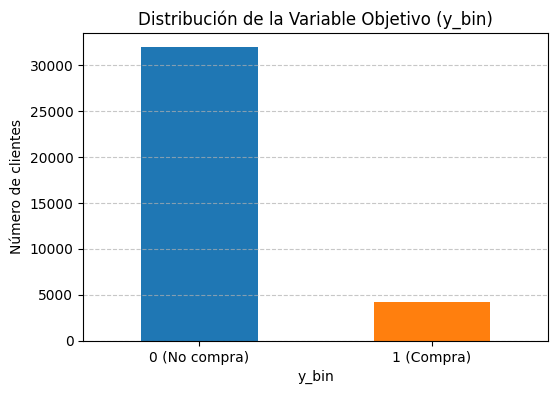

In [10]:
# comprobamos el nivel de desbalanceo en el train
print("--- TASA DE CONVERSIÓN EN TRAIN ---")
print((y_train.value_counts(normalize=True) * 100).round(2).astype(str) + '%')

# visualizacion del desbalanceo
fig, ax = plt.subplots(figsize=(6, 4))
y_train.value_counts().plot(kind='bar', color=['#1f77b4', '#ff7f0e'], ax=ax)
plt.title("Distribución de la Variable Objetivo (y_bin)")
plt.xticks(ticks=[0, 1], labels=['0 (No compra)', '1 (Compra)'], rotation=0)
plt.ylabel("Número de clientes")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# aislamos la lista de features predictoras
# como ya hicimos el one-hot encoding, ahora todas nuestras columnas son numericas
features = [c for c in X_train.columns if c != 'y_bin']

## 3. Modelo 1: Regresión Logística (Modelo Baseline)
La Regresión Logística nos servirá como modelo *Baseline*. Es altamente interpretable y nos permite establecer un suelo de rendimiento a batir mediante los *Odds Ratios*.

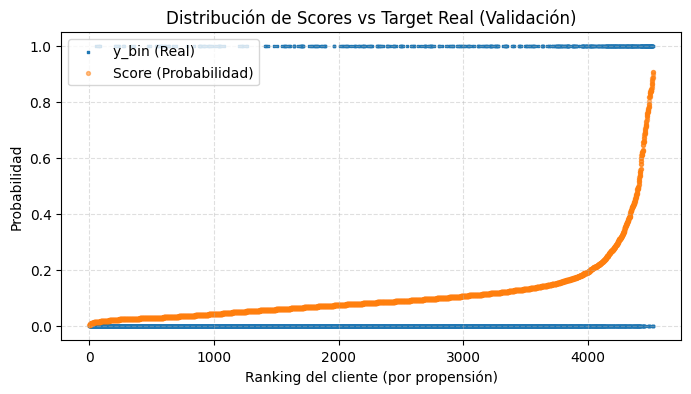


--- TOP 10 VARIABLES (COEFICIENTES REG. LOGÍSTICA) ---


,feature,coef,coef_exp_odds_ratio,rank,contribution
40,poutcome_success,2.019232,7.532536,1.0,+
23,contact_unknown,-1.225757,0.293536,2.0,-
32,month_nov,-0.864613,0.421215,3.0,-
24,month_aug,-0.789889,0.453895,4.0,-
30,month_mar,0.757088,2.132059,5.0,+
27,month_jan,-0.699563,0.496802,6.0,-
41,poutcome_unknown,-0.676453,0.508417,7.0,-
33,month_oct,0.635404,1.887784,8.0,+
34,month_sep,0.547381,1.728720,9.0,+
28,month_jul,-0.543751,0.580567,10.0,-


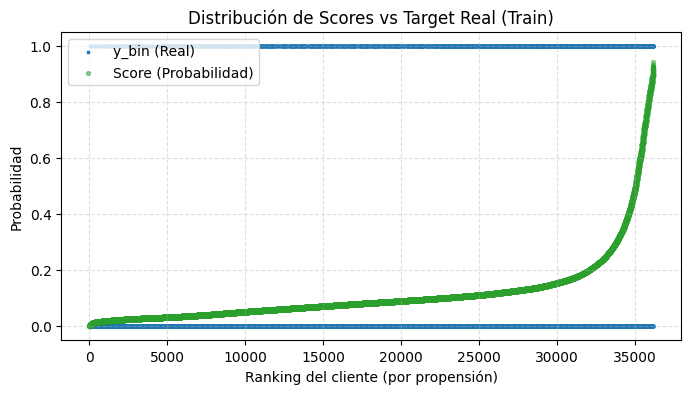

In [11]:
# entrenamos el modelo baseline
# subimos max_iter a 1000 para que el algoritmo converja sin dar warnings
logreg = LogisticRegression(max_iter=1000, random_state=28)
logreg.fit(X_train[features], y_train)

# generamos las probabilidades (scores) SOBRE VALIDACIÓN
y_hat_logreg = logreg.predict_proba(X_val[features])[:, 1]
y_hat_logreg_rank = pd.Series(y_hat_logreg).rank()

# ploteamos como distribuye el modelo las probabilidades frente a la realidad
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(y_hat_logreg_rank, y_val, s=2, c='#1f77b4', marker="s", label='y_bin (Real)')
ax.scatter(y_hat_logreg_rank, y_hat_logreg, s=8, c='#ff7f0e', marker="o", alpha=0.5, label='Score (Probabilidad)')
plt.title("Distribución de Scores vs Target Real (Validación)")
plt.xlabel("Ranking del cliente (por propensión)")
plt.ylabel("Probabilidad")
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# extraemos los coeficientes para determinar las features mas importantes
coef = pd.DataFrame({
    'feature': features,
    'coef': logreg.coef_[0],
    'coef_exp_odds_ratio': np.exp(logreg.coef_[0])
})

# rankeamos las variables por su impacto absoluto (ya sea positivo o negativo a la venta)
coef['rank'] = np.abs(coef.coef).rank(method='first', ascending=False)
coef.sort_values('rank', inplace=True)
coef['contribution'] = np.where(coef.coef_exp_odds_ratio > 1, '+', '-')

print("\n--- TOP 10 VARIABLES (COEFICIENTES REG. LOGÍSTICA) ---")
display(coef.head(10))

# evaluamos tambien sobre el train para tener la comparativa visual
y_train_logreg = logreg.predict_proba(X_train[features])[:, 1]
y_train_logreg_rank = pd.Series(y_train_logreg).rank()

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(y_train_logreg_rank, y_train, s=2, c='#1f77b4', marker="s", label='y_bin (Real)')
ax.scatter(y_train_logreg_rank, y_train_logreg, s=8, c='#2ca02c', marker="o", alpha=0.5, label='Score (Probabilidad)')
plt.title("Distribución de Scores vs Target Real (Train)")
plt.xlabel("Ranking del cliente (por propensión)")
plt.ylabel("Probabilidad")
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

Accuracy Base (Threshold 0.5): 0.8958


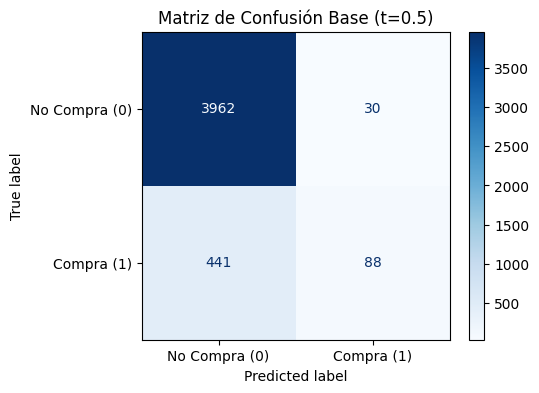

--- MÉTRICAS DE NEGOCIO (t=0.5) ---
Precisión: 0.7458
Recall: 0.1664


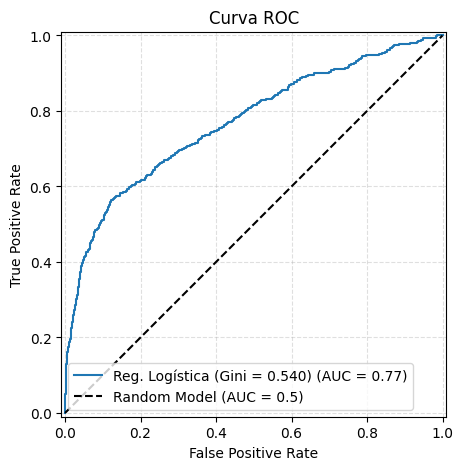

In [20]:
# evaluamos el modelo con el threshold por defecto (0.5) para establecer el baseline
print(f"Accuracy Base (Threshold 0.5): {accuracy_score(y_val, y_hat_logreg >= 0.5):.4f}")

# obtenemos la matriz de confusion
tn, fp, fn, tp = confusion_matrix(y_val, y_hat_logreg >= 0.5).ravel()

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_hat_logreg >= 0.5,
    cmap=plt.cm.Blues,
    display_labels=['No Compra (0)', 'Compra (1)'],
    ax=ax
)
plt.title("Matriz de Confusión Base (t=0.5)")
plt.show()

# metricas de negocio
print("--- MÉTRICAS DE NEGOCIO (t=0.5) ---")
print(f"Precisión: {precision_score(y_val, y_hat_logreg >= 0.5):.4f}")
print(f"Recall: {recall_score(y_val, y_hat_logreg >= 0.5):.4f}")

# curva roc y gini (metrica estandar en credit scoring y propension)
fpr, tpr, thresholds_roc = roc_curve(y_val, y_hat_logreg)
roc_auc = auc(fpr, tpr)
gini = 2 * roc_auc - 1

fig, ax = plt.subplots(figsize=(6, 5))
display_roc = RocCurveDisplay(
    fpr=fpr,
    tpr=tpr,
    roc_auc=roc_auc,
    estimator_name=f'Reg. Logística (Gini = {gini:.3f})'
)
display_roc.plot(ax=ax)
plt.plot([0, 1], [0, 1], "k--", label="Random Model (AUC = 0.5)")
plt.title("Curva ROC")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()

# 3.1 Estrategia de Negocio: aplicar un corte (Top 5%)
El umbral por defecto de `0.5` no es realista para campañas de telemarketing debido a las restricciones de presupuesto del call center. Vamos a ordenar los clientes por su score y llamar tan solo al top 5% con mayor propensión de compra.

In [14]:
# fijamos el porcentaje de corte
pct_corte = 0.05

# puntuamos a toda la base de clientes
probs_train = logreg.predict_proba(X_train[features])[:, 1]
probs_val = logreg.predict_proba(X_val[features])[:, 1]

# rankeamos y aplicamos el corte en el train
probs_train_series = pd.Series(probs_train, index=X_train.index).sort_values(ascending=False)
corte_train = int(pct_corte * len(X_train))
preds_train = pd.Series(0, index=X_train.index)
preds_train.loc[probs_train_series.head(corte_train).index] = 1

# rankeamos y aplicamos el corte en validacion
probs_val_series = pd.Series(probs_val, index=X_val.index).sort_values(ascending=False)
corte_val = int(pct_corte * len(X_val))
preds_val = pd.Series(0, index=X_val.index)
preds_val.loc[probs_val_series.head(corte_val).index] = 1

# evaluamos las metricas con el nuevo corte
def generar_tabla_metricas(y_real, y_proba, preds_cortadas):
    metricas = {
        'Accuracy': accuracy_score(y_real, preds_cortadas),
        'Precision': precision_score(y_real, preds_cortadas, zero_division=0),
        'Recall': recall_score(y_real, preds_cortadas),
        'AUC': roc_auc_score(y_real, y_proba),
        'Gini': 2 * roc_auc_score(y_real, y_proba) - 1
    }

    return pd.DataFrame({
        'Métrica': metricas.keys(),
        'Valor': metricas.values()
    }).round(4)

print(f"--- MÉTRICAS VALIDACIÓN (Top {pct_corte*100:.0f}%) ---")
display(generar_tabla_metricas(y_val, probs_val, preds_val))

--- MÉTRICAS VALIDACIÓN (Top 5%) ---


,Métrica,Valor
0,Accuracy,0.8936
1,Precision,0.6062
2,Recall,0.2590
3,AUC,0.7701
4,Gini,0.5401


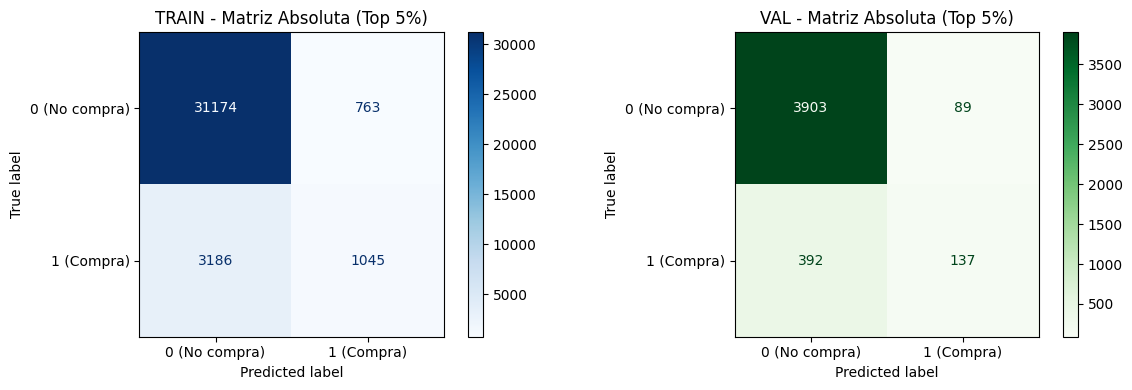

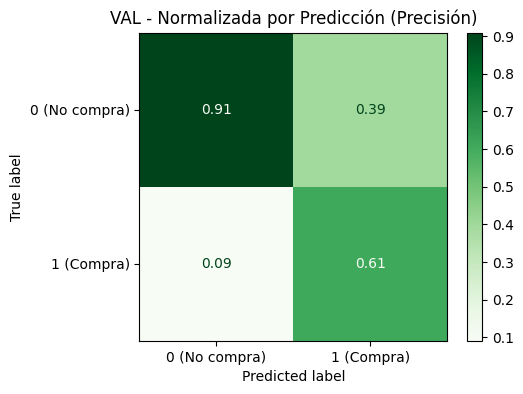

In [15]:
# evaluamos la estabilidad del modelo comparando las matrices absolutas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# matriz train
cm_train = confusion_matrix(y_train, preds_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['0 (No compra)', '1 (Compra)'])
disp_train.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f"TRAIN - Matriz Absoluta (Top {pct_corte*100:.0f}%)")

# matriz validacion
cm_val = confusion_matrix(y_val, preds_val)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=['0 (No compra)', '1 (Compra)'])
disp_val.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title(f"VAL - Matriz Absoluta (Top {pct_corte*100:.0f}%)")

plt.tight_layout()
plt.show()

# matriz normalizada por predicción en validacion
# las columnas suman 100%. nos muestra la tasa de acierto de las llamadas realizadas
fig, ax = plt.subplots(figsize=(5, 4))
cm_pred_norm = confusion_matrix(y_val, preds_val, normalize='pred')
disp_pred = ConfusionMatrixDisplay(confusion_matrix=cm_pred_norm, display_labels=['0 (No compra)', '1 (Compra)'])
disp_pred.plot(ax=ax, cmap='Greens', values_format='.2f')
plt.title(f"VAL - Normalizada por Predicción (Precisión)")
plt.show()

In [48]:
# comprobamos la probabilidad minima necesaria para entrar en el top 5%
umbral_corte = probs_val_series.iloc[corte_val - 1]
print(f"Threshold para el Top {pct_corte*100:.0f}%: {umbral_corte:.4f}")

# añadimos los resultados de la regresión logistica en la leaderboard
precision_logreg = float(precision_score(y_val, preds_val, zero_division=0))
recall_logreg = float(recall_score(y_val, preds_val, zero_division=0))
llamadas_logreg = int(sum(preds_val == 1))
ventas_logreg = int(sum((preds_val == 1) & (y_val == 1)))

# debe compilarse solo una vez para que no se dupliquen las filas
leaderboard_data.append({
    'Modelo': f'LogReg (Top {pct_corte*100:.0f}%)',
    'Nº Clientes': len(X_val),
    'Llamadas': llamadas_logreg,
    'Ventas': ventas_logreg,
    'Precision': f'{round(precision_logreg * 100, 2)}%',
    'Recall': f'{round(recall_logreg * 100, 2)}%'
})

display(pd.DataFrame(leaderboard_data))

Threshold para el Top 5%: 0.3547


,Modelo,Nº Clientes,Llamadas,Ventas,Precision,Recall
0,LogReg (Top 5%),4521,226,133,58.85%,25.14%


## 3.2 Curva de uplift y rentabilidad por percentil
Agrupamos a los clientes en percentiles para evaluar cuánto mejora la precisión de nuestro modelo frente a llamar a la gente de forma aleatoria:

In [22]:
# tabla base para el calculo del uplift en validacion
predictions = pd.DataFrame({
    "y": y_val.values,  # aseguramos que sea array para evitar problemas de indices
    "y_hat": probs_val
})

# se añaden los percentiles del score a cada individuo
predictions['TopPercentile'] = np.ceil(100 * (-predictions.y_hat).rank(method='first', pct=True)).round(2).astype(int)

# se agrupan las predicciones por cada tramo del 1%
report = (
    predictions
    .groupby('TopPercentile')
    .agg(
        ScoreAvg=pd.NamedAgg('y_hat', np.mean),
        TotalCount=pd.NamedAgg('y', 'count'),
        Class1Count=pd.NamedAgg('y', np.sum)
    )
    .reset_index()
    .sort_values('TopPercentile')
)

# calculamos los acumulados para montar la curva
report['Class0Count'] = report.TotalCount - report.Class1Count
report['TotalCountCumulated'] = report.TotalCount.cumsum()
report['Class1CountCumulated'] = report.Class1Count.cumsum()
report['Class0CountCumulated'] = report.Class0Count.cumsum()

report['PrecisionCumulated'] = report.Class1CountCumulated / report.TotalCountCumulated
report['RecallCumulated'] = report.Class1CountCumulated / report.Class1Count.sum()
report['SpecificityCumulated'] = report.Class0CountCumulated / report.Class0Count.sum()

# calculamos el multiplicador del uplift
report['Class1TotalRatio'] = report.Class1Count.sum() / report.TotalCount.sum()
report['Class1TrivialUplift'] = report.Class1TotalRatio / report.Class1TotalRatio
report['Class1ModelUplift'] = report.PrecisionCumulated / report.Class1TotalRatio

percentil_corte = int(100 * pct_corte)

print("--- TABLA UPLIFT ---")
display(report.head(percentil_corte + 1))

# grafica interactiva de uplift
fig = go.Figure()

fig.add_trace(
    go.Bar(
        name="Fitted model",
        x=report.TopPercentile,
        y=report.Class1ModelUplift
    )
)

fig.add_trace(
    go.Scatter(
        name="Trivial model",
        x=report.TopPercentile,
        y=report.Class1TrivialUplift,
        hoverinfo='none',
        line=dict(color='red', width=2, dash='dash')
    )
)

# linea que marca visualmente donde dejamos de llamar por presupuesto
fig.add_vline(
    x=pct_corte * 100 + 0.5,
    line_width=2,
    line_dash="dash",
    line_color="black",
    annotation_text=f"Corte estrategico (Top {int(pct_corte*100)}%)",
    annotation_position="top right"
)

fig.update_layout(
    title='Curva de uplift (sobre validacion)',
    xaxis_title="Top percentil",
    yaxis_title="Uplift del modelo",
    showlegend=True,
    template='plotly_white'
)
fig.show()

--- TABLA UPLIFT ---


,TopPercentile,ScoreAvg,TotalCount,Class1Count,Class0Count,TotalCountCumulated,Class1CountCumulated,Class0CountCumulated,PrecisionCumulated,RecallCumulated,SpecificityCumulated,Class1TotalRatio,Class1TrivialUplift,Class1ModelUplift
0,1,0.830670,45,37,8,45,37,8,0.822222,0.069943,0.002004,0.11701,1.0,7.026969
1,2,0.687130,45,36,9,90,73,17,0.811111,0.137996,0.004259,0.11701,1.0,6.932010
2,3,0.530790,45,21,24,135,94,41,0.696296,0.177694,0.010271,0.11701,1.0,5.950767
3,4,0.437896,45,22,23,180,116,64,0.644444,0.219282,0.016032,0.11701,1.0,5.507624
4,5,0.377990,46,21,25,226,137,89,0.606195,0.258979,0.022295,0.11701,1.0,5.180730
5,6,0.327271,45,18,27,271,155,116,0.571956,0.293006,0.029058,0.11701,1.0,4.888113


## 4. Modelo 2: Árbol de Decisión (CART)

In [23]:
# funcion auxiliar para extraer las reglas de negocio del arbol de decision
# transforma la estructura interna del modelo en un dataframe legible
def tree_to_code(tree, feature_names, round_dec=2):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != sklearn.tree._tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]
    paths = []
    path = []

    def recurse(node, depth, path):
        if tree_.feature[node] != sklearn.tree._tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = round(tree_.threshold[node], round_dec)

            # rama izquierda (cumple la condicion)
            path.append(f"{name} <= {threshold}")
            recurse(tree_.children_left[node], depth + 1, path)
            path.pop()

            # rama derecha (no cumple la condicion)
            path.append(f"{name} > {threshold}")
            recurse(tree_.children_right[node], depth + 1, path)
            path.pop()
        else:
            proporcion_si = tree_.value[node][0][1]
            total_clientes_nodo = tree_.n_node_samples[node]
            num_si = proporcion_si * total_clientes_nodo

            # pasamos a porcentaje para que la regla sea facil de interpretar
            porcentaje = proporcion_si * 100

            path.append(f"-> SI COMPRAN: {porcentaje:.1f}% ({int(num_si)} clientes de {total_clientes_nodo})")
            paths.append(list(path))
            path.pop()

    recurse(0, 1, path)

    max_depth = max(len(path) for path in paths)
    columns = [f"Condition_{i+1}" for i in range(max_depth - 1)] + ["Prediction"]

    return pd.DataFrame(paths, columns=columns)

In [24]:
# optimizacion de hiperparametros del arbol (CART)
# usamos optuna para maximizar la precision en nuestro top 5%
def objective(trial):
    pct_corte = trial.suggest_float('pct_corte', 0.05, 0.05) # forzamos el corte
    profundidad = trial.suggest_int('max_depth', 3, 6)
    hojas = trial.suggest_int('min_samples_leaf', 20, 150)

    # entrenamiento sobre todo el train
    modelo = DecisionTreeClassifier(
        max_depth=profundidad,
        min_samples_leaf=hojas,
        random_state=28
    )
    modelo.fit(X_train[features], y_train)

    # prediccion sobre validacion
    probs_val = modelo.predict_proba(X_val[features])[:, 1]

    # logica de desempate
    # si el arbol asigna la misma probabilidad a muchos clientes, usamos el azar para desempatar
    np.random.seed(28)
    df_desempate_val = pd.DataFrame({
        'prob': probs_val,
        'azar': np.random.rand(len(probs_val))
    }, index=X_val.index)

    df_desempate_val = df_desempate_val.sort_values(by=['prob', 'azar'], ascending=[False, True])

    # aplicacion del corte
    corte_val = int(pct_corte * len(X_val))
    indices_llamar = df_desempate_val.head(corte_val).index

    preds_val = pd.Series(0, index=X_val.index)
    preds_val.loc[indices_llamar] = 1

    precision_v = precision_score(y_val, preds_val, zero_division=0)
    return precision_v

# lanzamos la funcion con 500 intentos
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=28))
study.optimize(objective, n_trials=500)

print("--- TOP 5 ÁRBOLES DESCUBIERTOS POR OPTUNA ---")

# filtramos los intentos exitosos
intentos_validos = [t for t in study.trials if t.state.name == "COMPLETE" and t.value > 0.0]

if len(intentos_validos) == 0:
    print("Ningún modelo superó las reglas de negocio")
else:
    # ordenamos de mayor a menor precision
    intentos_ordenados = sorted(intentos_validos, key=lambda x: x.value, reverse=True)

    resultados_top5 = []
    precisiones_vistas = set()
    modelos_en_top = 0

    for trial in intentos_ordenados:
        if modelos_en_top >= 5:
            break

        pct_corte_opt = trial.params['pct_corte']
        prof_opt = trial.params['max_depth']
        hojas_opt = trial.params['min_samples_leaf']

        # reentrenamos el modelo para extraer todas sus metricas
        modelo = DecisionTreeClassifier(max_depth=prof_opt, min_samples_leaf=hojas_opt, random_state=28)
        modelo.fit(X_train[features], y_train)

        # metricas en train
        probs_train = modelo.predict_proba(X_train[features])[:, 1]
        np.random.seed(28)
        df_desempate_train = pd.DataFrame({
            'prob': probs_train,
            'azar': np.random.rand(len(probs_train))
        }, index=X_train.index).sort_values(by=['prob', 'azar'], ascending=[False, True])

        corte_train_opt = int(pct_corte_opt * len(X_train))
        preds_train = pd.Series(0, index=X_train.index)
        preds_train.loc[df_desempate_train.head(corte_train_opt).index] = 1

        prec_t = precision_score(y_train, preds_train, zero_division=0)
        recall_t = recall_score(y_train, preds_train)
        llamadas_t = int(sum(preds_train == 1))

        # metricas en validacion
        probs_val = modelo.predict_proba(X_val[features])[:, 1]
        np.random.seed(28)
        df_desempate_val = pd.DataFrame({
            'prob': probs_val,
            'azar': np.random.rand(len(probs_val))
        }, index=X_val.index).sort_values(by=['prob', 'azar'], ascending=[False, True])

        corte_val_opt = int(pct_corte_opt * len(X_val))
        preds_val = pd.Series(0, index=X_val.index)
        preds_val.loc[df_desempate_val.head(corte_val_opt).index] = 1

        prec_v = precision_score(y_val, preds_val, zero_division=0)

        # filtro para no mostrar modelos casi identicos
        prec_v_redondeada = round(prec_v, 4)
        if prec_v_redondeada in precisiones_vistas:
            continue

        precisiones_vistas.add(prec_v_redondeada)

        recall_v = recall_score(y_val, preds_val)
        llamadas_v = int(sum(preds_val == 1))
        ventas_v = int(sum((preds_val == 1) & (y_val == 1)))

        resultados_top5.append({
            'Ranking': modelos_en_top + 1,
            'Corte_VIP': f"{pct_corte_opt*100:.1f}%",
            'Modelo': f"CART (Prof:{prof_opt}, Hojas:{hojas_opt})",
            'Llamadas_Val': llamadas_v,
            'Ventas_Val': ventas_v,
            'Prec_Val_%': round(prec_v * 100, 2),
            'Recall_Val_%': round(recall_v * 100, 2),
            'Llamadas_Train': llamadas_t,
            'Prec_Train_%': round(prec_t * 100, 2),
            'Recall_Train_%': round(recall_t * 100, 2)
        })

        modelos_en_top += 1

    # salida
    df_top5 = pd.DataFrame(resultados_top5).sort_values(by='Prec_Val_%', ascending=False).reset_index(drop=True)
    df_top5['Ranking'] = range(1, len(df_top5) + 1)
    display(df_top5)

--- TOP 5 ÁRBOLES DESCUBIERTOS POR OPTUNA ---


,Ranking,Corte_VIP,Modelo,Llamadas_Val,Ventas_Val,Prec_Val_%,Recall_Val_%,Llamadas_Train,Prec_Train_%,Recall_Train_%
0,1,5.0%,"CART (Prof:3, Hojas:72)",226,141,62.39,26.65,1808,58.08,24.82
1,2,5.0%,"CART (Prof:4, Hojas:119)",226,140,61.95,26.47,1808,58.19,24.86
2,3,5.0%,"CART (Prof:4, Hojas:86)",226,135,59.73,25.52,1808,57.91,24.75
3,4,5.0%,"CART (Prof:5, Hojas:130)",226,134,59.29,25.33,1808,58.08,24.82
4,5,5.0%,"CART (Prof:4, Hojas:41)",226,133,58.85,25.14,1808,58.68,25.08


## 4.1 Entrenamiento y extracción de reglas del modelo seleccionado
Analizando el ranking de optuna, seleccionamos el modelo número 3 (profundidad 4, mínimo 86 individuos por hoja). Buscamos el hiperparámetro más estable: la diferencia de precisión entre el conjunto de train (57.9%) y el de validación (59.7%) es menor que en los otros dos modelos, lo que nos garantiza una buena generalización y un modelo robusto y fácil de interpretar.

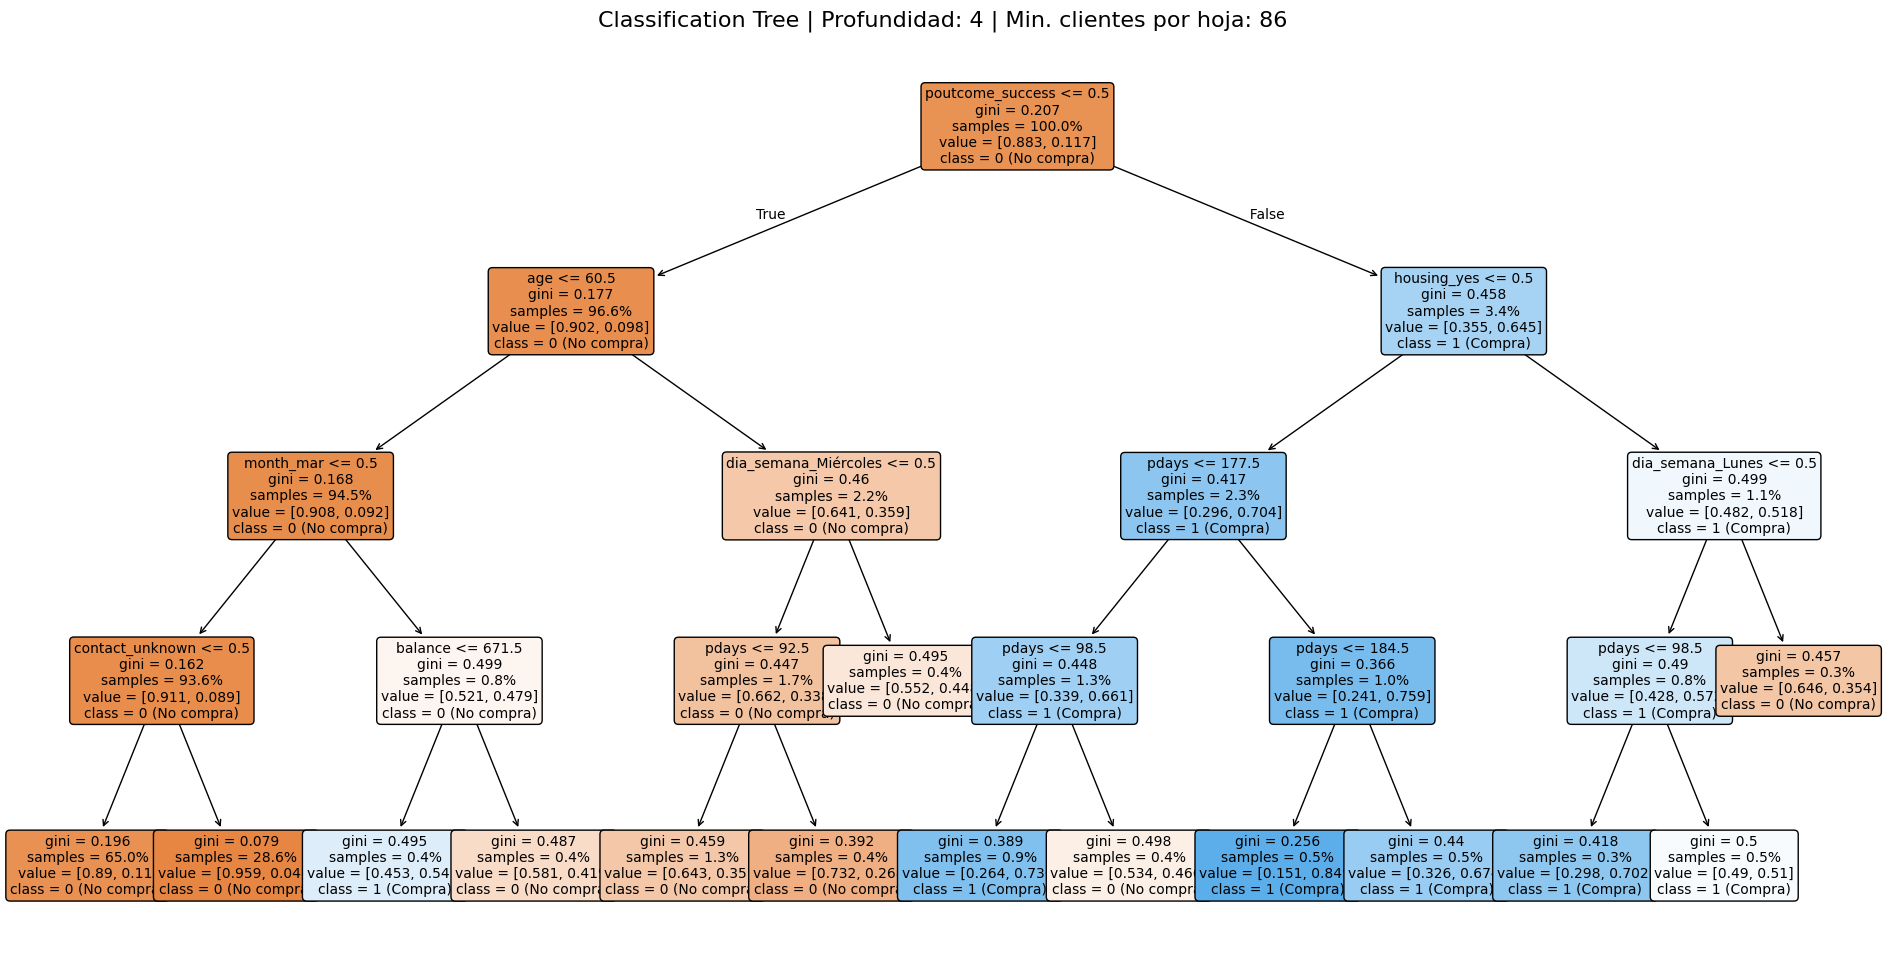

--- REGLAS DE DECISIÓN (LÓGICA DE NEGOCIO) ---


,Condition_1,Condition_2,Condition_3,Condition_4,Prediction
0,poutcome_success <= 0.5,age <= 60.5,month_mar <= 0.5,contact_unknown <= 0.5,-> SI COMPRAN: 11.0% (2591 clientes de 23520)
1,poutcome_success <= 0.5,age <= 60.5,month_mar <= 0.5,contact_unknown > 0.5,-> SI COMPRAN: 4.1% (427 clientes de 10350)
2,poutcome_success <= 0.5,age <= 60.5,month_mar > 0.5,balance <= 671.5,-> SI COMPRAN: 54.7% (75 clientes de 137)
3,poutcome_success <= 0.5,age <= 60.5,month_mar > 0.5,balance > 671.5,-> SI COMPRAN: 41.9% (65 clientes de 155)
4,poutcome_success <= 0.5,age > 60.5,dia_semana_Miércoles <= 0.5,pdays <= 92.5,-> SI COMPRAN: 35.7% (174 clientes de 487)
5,poutcome_success <= 0.5,age > 60.5,dia_semana_Miércoles <= 0.5,pdays > 92.5,-> SI COMPRAN: 26.8% (37 clientes de 138)
6,poutcome_success <= 0.5,age > 60.5,dia_semana_Miércoles > 0.5,-> SI COMPRAN: 44.8% (69 clientes de 154),None
7,poutcome_success > 0.5,housing_yes <= 0.5,pdays <= 177.5,pdays <= 98.5,-> SI COMPRAN: 73.6% (251 clientes de 341)
8,poutcome_success > 0.5,housing_yes <= 0.5,pdays <= 177.5,pdays > 98.5,-> SI COMPRAN: 46.6% (61 clientes de 131)
9,poutcome_success > 0.5,housing_yes <= 0.5,pdays > 177.5,pdays <= 184.5,-> SI COMPRAN: 84.9% (152 clientes de 179)



--- IMPORTANCIA DE VARIABLES (GINI) ---


,Feature,Importance
40,poutcome_success,0.685678
0,age,0.104919
30,month_mar,0.085250
23,contact_unknown,0.065774
3,pdays,0.028867
20,housing_yes,0.017652
35,dia_semana_Lunes,0.006640
37,dia_semana_Miércoles,0.002913
1,balance,0.002306


In [25]:
# parametros del modelo seleccionado en optuna
pct_corte_opt = 0.05
prof_opt = 4
hojas_opt = 86

# entrenamos el modelo definitivo sobre el train
modelo_elegido = DecisionTreeClassifier(
    criterion='gini',
    splitter='best',
    max_depth=prof_opt,
    min_samples_leaf=hojas_opt,
    random_state=28
)
modelo_elegido.fit(X_train[features], y_train)

# --- dibujamos el arbol ---

# el modelo crea rapidamente hojas enormes en la izquierda para descartar a los clientes sin propension
# esto nos deja las ramas de la derecha limpias para encontrar a nuestro target
plt.figure(figsize=(24, 12))
plot_tree(
    modelo_elegido,
    filled=True,
    feature_names=features,
    class_names=['0 (No compra)', '1 (Compra)'],
    proportion=True,
    rounded=True,
    fontsize=10
)
plt.title(f"Classification Tree | Profundidad: {prof_opt} | Min. clientes por hoja: {hojas_opt}", fontsize=16)
plt.show()

# --- reglas de negocio del arbol ---

df_reglas = tree_to_code(modelo_elegido, features)

print("--- REGLAS DE DECISIÓN (LÓGICA DE NEGOCIO) ---")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
display(df_reglas)

# --- importancia de las variables ---

importances = pd.DataFrame({
    'Feature': features,
    'Importance': modelo_elegido.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n--- IMPORTANCIA DE VARIABLES (GINI) ---")
# usamos display para renderizar la tabla html y filtramos las variables que el arbol ha ignorado
display(importances[importances['Importance'] > 0])

El principal problema de un árbol de decisión simple es que todos los clientes que caen en la misma hoja final reciben exactamente la misma probabilidad.Ssi nuestro 5% corta por el medio de una de estas hojas, el modelo se ve obligado a desempatar por puro azar. Esta limitación es la que justifica dar el salto a modelos de ensamble (random forest) para conseguir un score mucho más específico.

In [49]:
# extraemos las probabilidades del cart sobre el set de validacion
probs_val_cart = modelo_elegido.predict_proba(X_val[features])[:, 1]

# aplicamos el desempate por azar
np.random.seed(28)
df_desempate_cart = pd.DataFrame({
    'prob': probs_val_cart,
    'azar': np.random.rand(len(probs_val_cart))
}, index=X_val.index)

df_desempate_cart = df_desempate_cart.sort_values(by=['prob', 'azar'], ascending=[False, True])

# ejecutamos el corte
corte_val_camp = int(pct_corte_opt * len(X_val))
indices_val_cart = df_desempate_cart.head(corte_val_camp).index

preds_val_cart = pd.Series(0, index=X_val.index)
preds_val_cart.loc[indices_val_cart] = 1

# extraccion de metricas finales
prec_v = precision_score(y_val, preds_val_cart, zero_division=0)
recall_v = recall_score(y_val, preds_val_cart, zero_division=0)
llamadas_v = int(sum(preds_val_cart == 1))
ventas_v = int(sum((preds_val_cart == 1) & (y_val == 1)))

# actualizacion de la lista de modelos (compilar solo una vez)
leaderboard_data.append({
    'Modelo': f'CART (Top {pct_corte_opt*100:.0f}%)',
    'Nº Clientes': len(X_val),
    'Llamadas': llamadas_v,
    'Ventas': ventas_v,
    'Precision': f'{round(prec_v * 100, 2)}%',
    'Recall': f'{round(recall_v * 100, 2)}%'
})

print("--- LEADERBOARD ACTUALIZADO ---")
display(pd.DataFrame(leaderboard_data))

--- LEADERBOARD ACTUALIZADO ---


,Modelo,Nº Clientes,Llamadas,Ventas,Precision,Recall
0,LogReg (Top 5%),4521,226,133,58.85%,25.14%
1,CART (Top 5%),4521,226,135,59.73%,25.52%


## 5. Modelo 3: Random Forest

In [30]:
# estimacion del coste computacional de un bosque denso
print("Entrenando random forest de 500 árboles...")
inicio = time.time()

# usamos n_jobs=-1 para trabajar en paralelo y exprimir todos los nucleos de la cpu
rf_prueba = RandomForestClassifier(
    n_estimators=500,
    n_jobs=-1,
    random_state=28
)
rf_prueba.fit(X_train[features], y_train)

fin = time.time()
print(f"Tiempo de ejecución: {round(fin - inicio, 2)} segundos")

Entrenando random forest de 500 árboles...
Tiempo de ejecución: 29.5 segundos


In [31]:
# optimizacion del random forest maximizando precision sobre el top 5%
# fijamos n_estimators a 300 ya que por el teorema central del limite el error converge y no overfittea
def objective_rf_precision(trial):
    pct_corte = trial.suggest_float('pct_corte', 0.05, 0.05)

    # nuevos hiperparametros a optimizar
    profundidad = trial.suggest_int('max_depth', 4, 15)
    hojas = trial.suggest_int('min_samples_leaf', 10, 50)
    division = trial.suggest_int('min_samples_split', 20, 100)
    frac_variables = trial.suggest_float('max_features', 0.3, 0.9)

    rf = RandomForestClassifier(
        n_estimators=300, # fijo y suficientemente grande
        max_depth=profundidad,
        min_samples_leaf=hojas,
        min_samples_split=division,
        max_features=frac_variables,
        n_jobs=-1,
        random_state=28
    )
    rf.fit(X_train[features], y_train)

    # extraccion de probabilidades reales del bosque
    probs_rf_actual = rf.predict_proba(X_val[features])[:, 1]

    # desempate usando las nuevas probabilidades
    np.random.seed(28)
    df_desempate_val = pd.DataFrame({
        'prob': probs_rf_actual,
        'azar': np.random.rand(len(probs_rf_actual))
    }, index=X_val.index)

    # ordenamos de mayor a menor probabilidad
    df_desempate_val = df_desempate_val.sort_values(by=['prob', 'azar'], ascending=[False, True])

    # aplicacion del corte
    corte_val = int(pct_corte * len(X_val))
    indices_llamar = df_desempate_val.head(corte_val).index

    preds_campana = pd.Series(0, index=X_val.index)
    preds_campana.loc[indices_llamar] = 1

    return precision_score(y_val, preds_campana, zero_division=0)

print("Optimizando hiperparámetros del random forest...")

# semilla en el sampler para que haya reproducibilidad
study_prec = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=28))
study_prec.optimize(objective_rf_precision, n_trials=150)

Optimizando hiperparámetros del random forest...


In [32]:
# generacion del ranking top 5 de modelos random forest
def generar_ranking_rf(study):
    df_trials = study.trials_dataframe()
    df_exitos = df_trials[df_trials['state'] == 'COMPLETE'].copy()

    # ordenamos por valor objetivo (precision)
    top_trials = df_exitos.sort_values(by=['value', 'number'], ascending=[False, True]).head(100)

    resultados_top5 = []
    precisiones_vistas = set()
    modelos_en_top = 0

    for i, row in top_trials.iterrows():
        if modelos_en_top >= 5:
            break

        # extraemos los parametros que encontro optuna
        pct_corte_opt = row['params_pct_corte']
        prof_opt = int(row['params_max_depth'])
        hojas_opt = int(row['params_min_samples_leaf'])
        division_opt = int(row['params_min_samples_split'])
        vars_opt = row['params_max_features']

        # reentrenamos el modelo con 300 arboles
        rf_temp = RandomForestClassifier(
            n_estimators=300,
            max_depth=prof_opt,
            min_samples_leaf=hojas_opt,
            min_samples_split=division_opt,
            max_features=vars_opt,
            n_jobs=-1,
            random_state=28
        )
        rf_temp.fit(X_train[features], y_train)

        # simulacion y corte en train
        probs_train = rf_temp.predict_proba(X_train[features])[:, 1]
        np.random.seed(28)
        df_desempate_train = pd.DataFrame({
            'prob': probs_train,
            'azar': np.random.rand(len(probs_train))
        }, index=X_train.index).sort_values(by=['prob', 'azar'], ascending=[False, True])

        corte_train_opt = int(pct_corte_opt * len(X_train))
        preds_train = pd.Series(0, index=X_train.index)
        preds_train.loc[df_desempate_train.head(corte_train_opt).index] = 1

        prec_t = precision_score(y_train, preds_train, zero_division=0)
        llamadas_t = int(preds_train.sum())

        # simulacion y corte en validacion
        probs_val = rf_temp.predict_proba(X_val[features])[:, 1]
        np.random.seed(28)
        df_desempate_val = pd.DataFrame({
            'prob': probs_val,
            'azar': np.random.rand(len(probs_val))
        }, index=X_val.index).sort_values(by=['prob', 'azar'], ascending=[False, True])

        corte_val_opt = int(pct_corte_opt * len(X_val))
        preds_val = pd.Series(0, index=X_val.index)
        preds_val.loc[df_desempate_val.head(corte_val_opt).index] = 1

        prec_v = precision_score(y_val, preds_val, zero_division=0)

        # filtro anticlon
        prec_v_redondeada = round(prec_v, 4)
        if prec_v_redondeada in precisiones_vistas:
            continue

        precisiones_vistas.add(prec_v_redondeada)

        diferencia_overfitting = (prec_t - prec_v) * 100
        recall_v = recall_score(y_val, preds_val, zero_division=0)
        llamadas_v = int(preds_val.sum())
        ventas_v = int(((preds_val == 1) & (y_val == 1)).sum())

        resultados_top5.append({
            'Ranking': modelos_en_top + 1,
            'Corte_VIP': f"{pct_corte_opt*100:.1f}%",
            'Modelo': f"RF (Prof:{prof_opt}, Hojas:{hojas_opt})",
            'Llamadas_Val': llamadas_v,
            'Ventas_Val': ventas_v,
            'Prec_Val_%': round(prec_v * 100, 2),
            'Recall_Val_%': round(recall_v * 100, 2),
            'Llamadas_Train': llamadas_t,
            'Prec_Train_%': round(prec_t * 100, 2),
            'Dif_Train_Val_%': round(diferencia_overfitting, 2)
        })

        modelos_en_top += 1

    df_top5 = pd.DataFrame(resultados_top5).sort_values(by='Prec_Val_%', ascending=False).reset_index(drop=True)
    df_top5['Ranking'] = range(1, len(df_top5) + 1)
    return df_top5

print("--- TOP 5 MODELOS RANDOM FOREST ---")
display(generar_ranking_rf(study_prec))

--- TOP 5 MODELOS RANDOM FOREST ---


,Ranking,Corte_VIP,Modelo,Llamadas_Val,Ventas_Val,Prec_Val_%,Recall_Val_%,Llamadas_Train,Prec_Train_%,Dif_Train_Val_%
0,1,5.0%,"RF (Prof:8, Hojas:32)",226,138,61.06,26.09,1808,64.05,2.99
1,2,5.0%,"RF (Prof:12, Hojas:33)",226,137,60.62,25.90,1808,65.38,4.76
2,3,5.0%,"RF (Prof:4, Hojas:38)",226,136,60.18,25.71,1808,59.68,-0.50
3,4,5.0%,"RF (Prof:15, Hojas:50)",226,135,59.73,25.52,1808,64.71,4.98
4,5,5.0%,"RF (Prof:7, Hojas:16)",226,134,59.29,25.33,1808,64.55,5.25


In [33]:
# extraemos el diccionario de hiperparametros completos directamente de la memoria de optuna
df_completo = study_prec.trials_dataframe()
df_exitos = df_completo[df_completo['state'] == 'COMPLETE']

# sacamos los parametros exactos del top 5
top5_params = df_exitos.sort_values(by=['value', 'number'], ascending=[False, True]).head(5)

columnas_parametros = [
    'value',
    'params_max_depth',
    'params_min_samples_leaf',
    'params_min_samples_split',
    'params_max_features'
]

print("--- HIPERPARAMETROS OCULTOS DEL TOP 5 ---")
display(top5_params[columnas_parametros].rename(columns={'value': 'Precision_Val'}))

--- HIPERPARAMETROS OCULTOS DEL TOP 5 ---


,Precision_Val,params_max_depth,params_min_samples_leaf,params_min_samples_split,params_max_features
142,0.610619,8,32,73,0.649282
146,0.610619,8,28,76,0.629804
0,0.606195,12,33,30,0.538555
51,0.606195,8,30,64,0.728684
53,0.606195,8,27,60,0.677662


## 5.1 Entrenamiento y evaluación del Random Forest definitivo
Analizando los resultados de optuna, seleccionamos el modelo con profundidad 8 y mínimo 32 individuos por hoja. Esta configuración presenta una tasa de sobreajuste de apenas el 2.99% entre el conjunto de entrenamiento y el de validación, lo que garantiza que el bosque está capturando patrones reales de negocio y no memorizando ruido.

In [50]:
# parametros del modelo ganador basado en su estabilidad (menor overfitting)
corte_ganador = 0.05
profundidad_ganador = 8
hojas_ganador = 32
division_ganador = 73
vars_ganador = 0.649282

# entrenamos el modelo sobre todo el train fijando 300 arboles para que el error converja
rf_campeon = RandomForestClassifier(
    n_estimators=300,
    max_depth=profundidad_ganador,
    min_samples_leaf=hojas_ganador,
    min_samples_split=division_ganador,
    max_features=vars_ganador,
    n_jobs=-1,
    random_state=28
)
rf_campeon.fit(X_train[features], y_train)

# extraemos probabilidades aplicando el desempate por azar
probs_campeon = rf_campeon.predict_proba(X_val[features])[:, 1]

np.random.seed(28)
df_desempate_campeon = pd.DataFrame({
    'prob': probs_campeon,
    'azar': np.random.rand(len(probs_campeon))
}, index=X_val.index).sort_values(by=['prob', 'azar'], ascending=[False, True])

# aplicamos el corte del top 5%
num_llamar_rf = int(corte_ganador * len(X_val))
preds_finales_rf = pd.Series(0, index=X_val.index)
preds_finales_rf.loc[df_desempate_campeon.head(num_llamar_rf).index] = 1

# calculamos las metricas finales
prec_rf = precision_score(y_val, preds_finales_rf, zero_division=0)
recall_rf = recall_score(y_val, preds_finales_rf, zero_division=0)
llamadas_rf = int(preds_finales_rf.sum())
ventas_rf = int(((preds_finales_rf == 1) & (y_val == 1)).sum())

# registramos el modelo en la tabla
leaderboard_data.append({
    'Modelo': f'Random Forest (Top {corte_ganador*100:.0f}%)',
    'Nº Clientes': len(X_val),
    'Llamadas': llamadas_rf,
    'Ventas': ventas_rf,
    'Precision': f'{round(prec_rf * 100, 2)}%',
    'Recall': f'{round(recall_rf * 100, 2)}%'
})

display(pd.DataFrame(leaderboard_data))

,Modelo,Nº Clientes,Llamadas,Ventas,Precision,Recall
0,LogReg (Top 5%),4521,226,133,58.85%,25.14%
1,CART (Top 5%),4521,226,135,59.73%,25.52%
2,Random Forest (Top 5%),4521,226,138,61.06%,26.09%


## 5.2 Importancia de las variables en el Random Forest
Calculamos el peso de cada variable para entender qué factores impulsan las predicciones del modelo. Esto nos permite comprobar si el bosque prioriza las mismas características que el CART o si ha encontrado valor en otras features.

In [36]:
# extraccion de la importancia de cada variable (basado en la reduccion de impureza del indice gini)
importances_rf = pd.DataFrame({
    'Feature': features,
    'Importance': rf_campeon.feature_importances_
}).sort_values('Importance', ascending=False)

print("--- TOP 10 VARIABLES MÁS IMPORTANTES (RANDOM FOREST) ---")
display(importances_rf.head(10))

--- TOP 10 VARIABLES MÁS IMPORTANTES (RANDOM FOREST) ---


,Feature,Importance
40,poutcome_success,0.434186
3,pdays,0.100681
0,age,0.091008
30,month_mar,0.059103
20,housing_yes,0.048650
29,month_jun,0.047403
23,contact_unknown,0.046603
33,month_oct,0.033232
1,balance,0.026697
34,month_sep,0.020271


## 6. Modelo 4: XGBoost
A diferencia del Random Forest, que entrena árboles independientes en paralelo, XGBoost utiliza un enfoque secuencial: cada nuevo árbol se centra exclusivamente en corregir los errores cometidos por los árboles anteriores. Optimizamos sus hiperparámetros buscando el equilibrio perfecto entre la tasa de aprendizaje y el número máximo de iteraciones.

In [37]:
# funcion objetivo para optimizar el modelo de gradient boosting
def objective_xgb_precision(trial):
    # fijamos la restriccion de negocio
    pct_corte = trial.suggest_float('pct_corte', 0.05, 0.05)

    # hiperparametros estructurales
    arboles = trial.suggest_int('n_estimators', 50, 400, step=15)
    profundidad = trial.suggest_int('max_depth', 2, 7)
    lr = trial.suggest_float('learning_rate', 0.01, 0.2)

    # hiperparametros de regularizacion y muestreo
    sub = trial.suggest_float('subsample', 0.6, 1.0)
    col = trial.suggest_float('colsample_bytree', 0.6, 1.0)
    gamma_val = trial.suggest_float('gamma', 0.0, 5.0)

    modelo = xgb.XGBClassifier(
        n_estimators=arboles,
        max_depth=profundidad,
        learning_rate=lr,
        subsample=sub,
        colsample_bytree=col,
        gamma=gamma_val,
        random_state=28,
        n_jobs=-1,
        eval_metric='logloss',
        tree_method='hist' # acelerador del proceso usando histogramas
    )

    # silenciamos los logs nativos de xgboost
    modelo.fit(X_train[features], y_train, verbose=False)

    probs_val = modelo.predict_proba(X_val[features])[:, 1]

    # desempate por azar para evitar sesgos de orden en el dataframe
    np.random.seed(28)
    df_desempate_val = pd.DataFrame({
        'prob': probs_val,
        'azar': np.random.rand(len(probs_val))
    }, index=X_val.index)

    df_desempate_val = df_desempate_val.sort_values(by=['prob', 'azar'], ascending=[False, True])

    corte_val = int(pct_corte * len(X_val))
    indices_llamar = df_desempate_val.head(corte_val).index

    preds_campana = pd.Series(0, index=X_val.index)
    preds_campana.loc[indices_llamar] = 1

    return precision_score(y_val, preds_campana, zero_division=0)

print("--- OPTIMIZANDO XGBOOST ---")

# 100 intentos son suficientes para que el optimizador converja
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=28))
study_xgb.optimize(objective_xgb_precision, n_trials=100)

--- OPTIMIZANDO XGBOOST ---


## 6.1 Extracción y evaluación del Top 5 de XGBoost
Al ser un modelo secuencial, XGBoost es propenso a memorizar el ruido si le damos demasiados árboles. Para evitarlo, aplicamos un Early Stopping de la siguiente manera: evaluamos el historial del modelo y lo cortamos en el árbol donde el error de validación fue mínimo. Además, aplicamos una penalización estricta descartando cualquier modelo cuya precisión en el train supere el 5% de diferencia respecto de validación.

In [39]:
# generacion del ranking top 5 de modelos xgboost
def generar_ranking_xgb(study, max_overfitting_pct=5.0):
    df_trials = study.trials_dataframe()
    df_exitos = df_trials[df_trials['state'] == 'COMPLETE'].copy()
    top_trials = df_exitos.sort_values(by='value', ascending=False).head(100)

    resultados_top5 = []
    precisiones_vistas = set()

    for i, row in top_trials.iterrows():
        pct_corte_opt = row['params_pct_corte']
        arboles_max = int(row['params_n_estimators'])
        prof_opt = int(row['params_max_depth'])
        lr_opt = row['params_learning_rate']
        sub_opt = row['params_subsample']
        col_opt = row['params_colsample_bytree']
        gamma_opt = row['params_gamma']

        # manteniendo la aceleracion por histogramas comentada antes
        modelo = xgb.XGBClassifier(
            n_estimators=arboles_max,
            max_depth=prof_opt,
            learning_rate=lr_opt,
            subsample=sub_opt,
            colsample_bytree=col_opt,
            gamma=gamma_opt,
            random_state=28,
            n_jobs=-1,
            eval_metric='logloss',
            tree_method='hist'
        )

        # pasamos los sets de evaluacion para que xgboost guarde el historial de aprendizaje
        conjuntos_evaluacion = [(X_train[features], y_train), (X_val[features], y_val)]
        modelo.fit(X_train[features], y_train, eval_set=conjuntos_evaluacion, verbose=False)

        # extraemos el log de errores para encontrar la iteracion exacta
        # en la que deja de aprender (sube el error del val)
        errores_val = modelo.evals_result()['validation_1']['logloss']
        mejor_arbol = errores_val.index(min(errores_val)) + 1

        # predecimos limitando el modelo estrictamente hasta ese arbol optimo
        probs_train = modelo.predict_proba(X_train[features], iteration_range=(0, mejor_arbol))[:, 1]
        probs_val = modelo.predict_proba(X_val[features], iteration_range=(0, mejor_arbol))[:, 1]

        # simulacion de la campana en train
        np.random.seed(28)
        df_desempate_train = pd.DataFrame({
            'prob': probs_train,
            'azar': np.random.rand(len(probs_train))
        }, index=X_train.index).sort_values(by=['prob', 'azar'], ascending=[False, True])

        corte_train_opt = int(pct_corte_opt * len(X_train))
        preds_train = pd.Series(0, index=X_train.index)
        preds_train.loc[df_desempate_train.head(corte_train_opt).index] = 1

        prec_t = precision_score(y_train, preds_train, zero_division=0)

        # simulacion de la campana en validacion
        np.random.seed(28)
        df_desempate_val = pd.DataFrame({
            'prob': probs_val,
            'azar': np.random.rand(len(probs_val))
        }, index=X_val.index).sort_values(by=['prob', 'azar'], ascending=[False, True])

        corte_val_opt = int(pct_corte_opt * len(X_val))
        preds_val = pd.Series(0, index=X_val.index)
        preds_val.loc[df_desempate_val.head(corte_val_opt).index] = 1

        prec_v = precision_score(y_val, preds_val, zero_division=0)
        diferencia_overfitting = (prec_t - prec_v) * 100

        # filtro estricto de negocio para descartar sobreajuste
        if diferencia_overfitting > max_overfitting_pct:
            continue

        # filtro anticlon para no repetir modelos con exacto rendimiento
        prec_v_redondeada = round(prec_v, 4)
        if prec_v_redondeada in precisiones_vistas:
            continue

        precisiones_vistas.add(prec_v_redondeada)

        ventas_v = int(sum((preds_val == 1) & (y_val == 1)))

        resultados_top5.append({
            'Corte_VIP': f"{pct_corte_opt*100:.1f}%",
            'Modelo': f"XGB (Arb:{mejor_arbol}, Prof:{prof_opt}, LR:{lr_opt:.3f})",
            'Subsample': round(sub_opt, 4),
            'Colsample': round(col_opt, 4),
            'Gamma': round(gamma_opt, 4),
            'Ventas_Val': ventas_v,
            'Prec_Val_%': round(prec_v * 100, 2),
            'Dif_Train_Val_%': round(diferencia_overfitting, 2),
            'Arboles_Maximos': arboles_max
        })

        if len(resultados_top5) >= 5:
            break

    if len(resultados_top5) > 0:
        df_res = pd.DataFrame(resultados_top5).sort_values(by=['Prec_Val_%', 'Ventas_Val'], ascending=[False, False])
        df_top5 = df_res.head(5).reset_index(drop=True)
        df_top5.insert(0, 'Ranking', range(1, len(df_top5) + 1))

        print("--- TOP 5 XGBOOST---")
        display(df_top5)
    else:
        print("Ningún modelo superó el filtro de overfitting. Prueba a subir el umbral.")

generar_ranking_xgb(study_xgb, max_overfitting_pct=5.0)

--- TOP 5 XGBOOST---


,Ranking,Corte_VIP,Modelo,Subsample,Colsample,Gamma,Ventas_Val,Prec_Val_%,Dif_Train_Val_%,Arboles_Maximos
0,1,5.0%,"XGB (Arb:116, Prof:6, LR:0.068)",0.8068,0.9978,3.7141,148,65.49,4.59,140
1,2,5.0%,"XGB (Arb:332, Prof:2, LR:0.126)",0.7268,0.9053,0.7814,144,63.72,0.28,365
2,3,5.0%,"XGB (Arb:199, Prof:3, LR:0.088)",0.6530,0.9723,1.6373,142,62.83,3.48,200
3,4,5.0%,"XGB (Arb:124, Prof:2, LR:0.190)",0.9687,0.7176,0.8314,137,60.62,1.44,125
4,5,5.0%,"XGB (Arb:183, Prof:3, LR:0.079)",0.7774,0.8332,4.1065,135,59.73,4.87,185


## 6.2 Selección del XGBoost definitivo
Al analizar el Top 5, nos encontramos dos modelos completamente distintos. El Modelo 1 alcanza la mayor de las precisiones (65.49%) con un riesgo controlado (4.59% de overfitting). Sin embargo, como el top 5% de validación lo forman 226 clientes, la ventaja frente al Modelo 2 (63.72%) es de apenas 4 ventas.

Ante una diferencia tan pequeña, seleccionamos el **Modelo 2** como definitivo por ser mucho más estable. Al estar formado por 332 árboles de profundidad 2, se logra anular el sobreajuste casi por completo (0.28%). En un caso real, sacrificar 4 ventas en validación a cambio de garantizar que el algoritmo no empeorará ante datos futuros es la decisión más adecuada.

In [51]:
# hiperparametros exactos del modelo ganador (el mas estable de optuna)
corte_ganador = 0.05
arboles_ganador = 332
profundidad_ganador = 2
lr_ganador = 0.126
sub_ganador = 0.7268
col_ganador = 0.9053
gamma_ganador = 0.7814

# entrenamiento del modelo
xgb_campeon = xgb.XGBClassifier(
    n_estimators=arboles_ganador,
    max_depth=profundidad_ganador,
    learning_rate=lr_ganador,
    subsample=sub_ganador,
    colsample_bytree=col_ganador,
    gamma=gamma_ganador,
    random_state=28,
    n_jobs=-1,
    eval_metric='logloss',
    tree_method='hist'
)
xgb_campeon.fit(X_train[features], y_train)

# extraccion de probabilidades
probs_campeon_xgb = xgb_campeon.predict_proba(X_val[features])[:, 1]

np.random.seed(28)
df_desempate_xgb = pd.DataFrame({
    'prob': probs_campeon_xgb,
    'azar': np.random.rand(len(probs_campeon_xgb))
}, index=X_val.index).sort_values(by=['prob', 'azar'], ascending=[False, True])

num_llamar_xgb = int(corte_ganador * len(X_val))
preds_finales_xgb = pd.Series(0, index=X_val.index)
preds_finales_xgb.loc[df_desempate_xgb.head(num_llamar_xgb).index] = 1

# calculo de metricas sobre validacion
prec_xgb = precision_score(y_val, preds_finales_xgb, zero_division=0)
recall_xgb = recall_score(y_val, preds_finales_xgb, zero_division=0)
llamadas_xgb = int(preds_finales_xgb.sum())
ventas_xgb = int(((preds_finales_xgb == 1) & (y_val == 1)).sum())

# registro en la leaderboard
leaderboard_data.append({
    'Modelo': f'XGBoost (Top 5%)',
    'Nº Clientes': len(X_val),
    'Llamadas': llamadas_xgb,
    'Ventas': ventas_xgb,
    'Precision': f'{round(prec_xgb * 100, 2)}%',
    'Recall': f'{round(recall_xgb * 100, 2)}%'
})

display(pd.DataFrame(leaderboard_data))

,Modelo,Nº Clientes,Llamadas,Ventas,Precision,Recall
0,LogReg (Top 5%),4521,226,133,58.85%,25.14%
1,CART (Top 5%),4521,226,135,59.73%,25.52%
2,Random Forest (Top 5%),4521,226,138,61.06%,26.09%
3,XGBoost (Top 5%),4521,226,142,62.83%,26.84%


## 6.3 Importancia de Variables del modelo XGBoost seleccionado
Para entender la lógica del algoritmo, extraemos y normalizamos las 5 métricas de importancia propias de XGBoost (gain, weight, cover, total_gain, total_cover). Priorizamos el **gain**, ya que no se limita a contar cuántas veces aparece una variable, sino que mide su impacto real en la precisión de las decisiones del modelo.

In [53]:
import functools
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

# extraemos las 5 metricas de importancia
importances = ['gain', 'weight', 'cover', 'total_gain', 'total_cover']
importance_list = [
    pd.DataFrame.from_dict(
        xgb_campeon.get_booster().get_score(importance_type=i),
        orient='index',
        columns=[i]
    )
    for i in importances
]

importance_df = functools.reduce(
    lambda x, y: pd.merge(x, y, how='outer', left_index=True, right_index=True),
    importance_list
)

# normalizamos para que se lea en porcentajes 0 a 1 y rellenamos nulos con 0
importance_df = importance_df.fillna(0)
importance_df_norm = (importance_df / importance_df.sum(axis=0)).round(4)

# ordenamos por la metrica reina gain y mostramos el top 10
print("--- TOP 10 VARIABLES MÁS IMPORTANTES (NORMALIZADAS) ---")
display(importance_df_norm.sort_values(by='gain', ascending=False).head(10))

--- TOP 10 VARIABLES MÁS IMPORTANTES (NORMALIZADAS) ---


,gain,weight,cover,total_gain,total_cover
poutcome_success,0.3384,0.0192,0.0262,0.2772,0.0210
month_mar,0.0718,0.0121,0.0322,0.0371,0.0163
contact_unknown,0.0589,0.0373,0.0326,0.0940,0.0511
housing_yes,0.0509,0.0272,0.0175,0.0593,0.0200
month_jun,0.0454,0.0141,0.0193,0.0274,0.0114
month_sep,0.0360,0.0121,0.0243,0.0186,0.0123
loan_yes,0.0359,0.0081,0.0314,0.0124,0.0106
month_oct,0.0341,0.0212,0.0165,0.0309,0.0147
marital_married,0.0218,0.0141,0.0301,0.0131,0.0178
month_dec,0.0205,0.0081,0.0349,0.0071,0.0118


## 6.4 Importancia de variables con SHAP values
Para superar las limitaciones de las métricas de importancia tradicionales, utilizamos SHAP values. Este enfoque desglosa la contribución exacta de cada variable sobre la predicción final. A diferencia del gain, los SHAP values nos permiten visualizar la dirección del impacto de las variables y entender el comportamiento del modelo tanto a nivel global como para casos individuales.

SHAP values calculados para 4521 clientes y 44 variables:


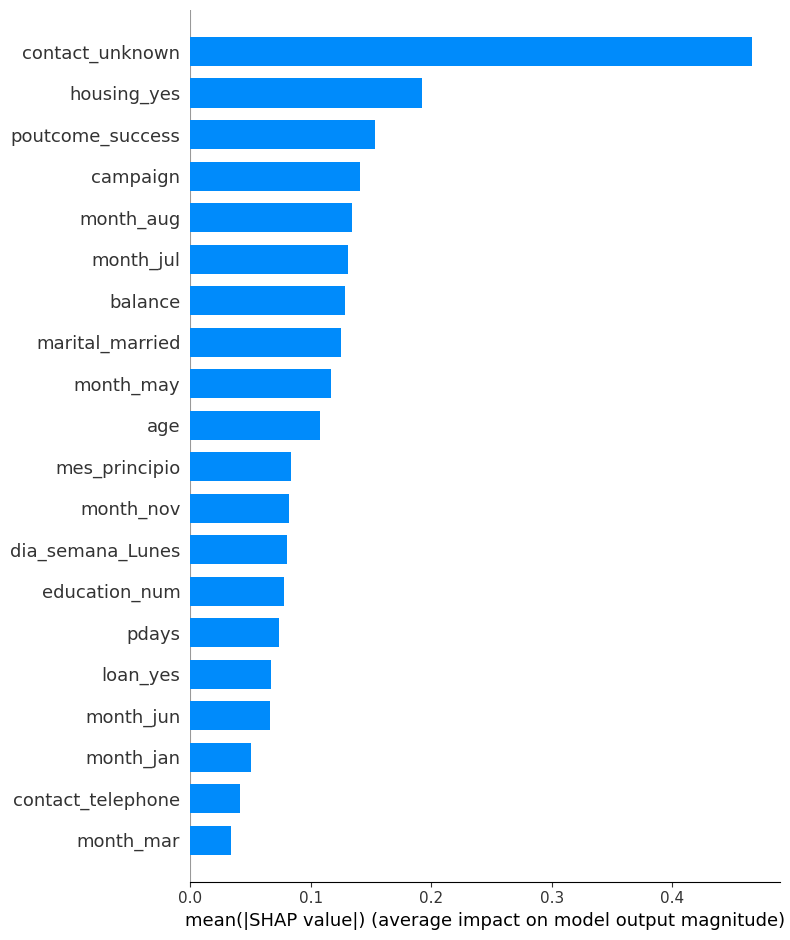

In [57]:
import shap

explainer_xgb = shap.TreeExplainer(xgb_campeon)

# calculamos los valores shap sobre validacion
shap_values_xgb = explainer_xgb.shap_values(X_val[features])

print(f"SHAP values calculados para {shap_values_xgb.shape[0]} clientes y {shap_values_xgb.shape[1]} variables:")

# grafico de barras para la importancia media absoluta
shap.summary_plot(
    shap_values_xgb,
    X_val[features],
    plot_type="bar",
    feature_names=features,
    show=False
)

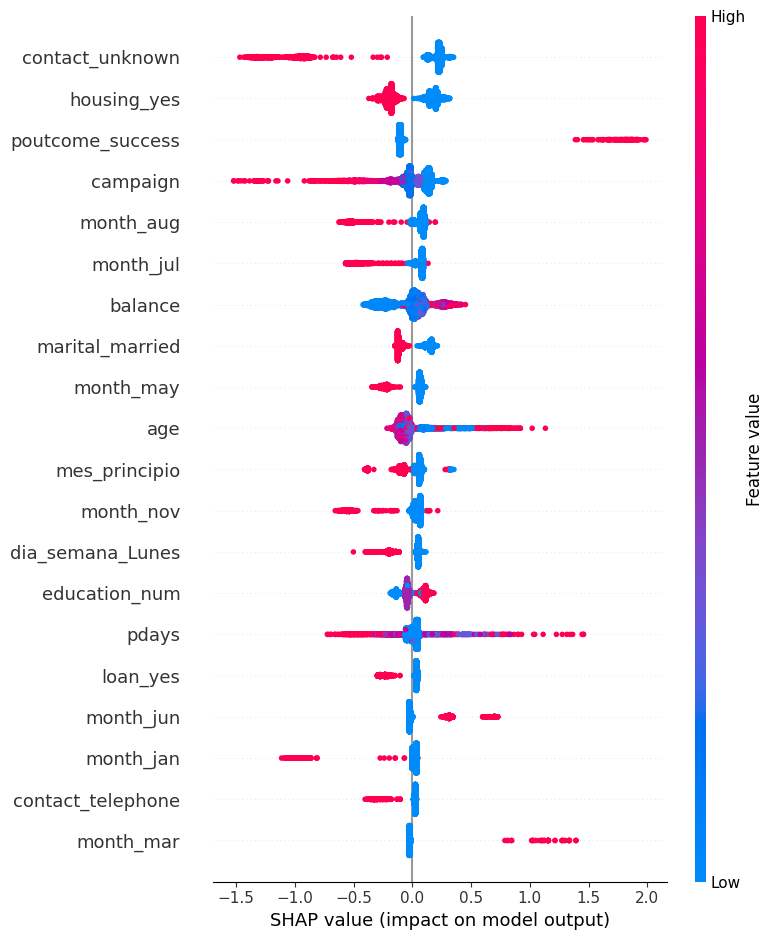

In [58]:
# grafico de puntos para el impacto y la direccion de la variable
shap.summary_plot(
    shap_values_xgb,
    X_val[features],
    feature_names=features
)

## 7. Impacto Económico y Simulador Financiero (testeo del modelo)
Para estimar el valor real de negocio generado por el modelo, realizamos una simulación sobre el set de test, formado por datos nunca vistos por el algoritmo. Traducimos las predicciones del modelo a métricas ejecutivas calculando los costes operativos de las llamadas (en función de su duración real) y los ingresos estimados basados en el balance de los clientes que aceptaron el depósito. Este análisis demuestra el retorno de la inversión (ROI) que se obtendría al desplegar el modelo en producción.

In [60]:
# parametros de negocio elegidos para la simulacion
corte_vip = 0.05 # solo llamamos al top 5%
pct_inversion = 0.30 # el cliente invierte el 30% de su balance
margen_banco = 0.02 # rentabilidad neta para el banco del 2% del dinero invertido
coste_llamada_minuto = 0.50 # coste del call center por minuto

# prediccion final en test con el campeon de xgboost usando las variables clave
probs_test = xgb_campeon.predict_proba(X_test[features])[:, 1]

# desempate estricto por azar
np.random.seed(28)
df_desempate_test = pd.DataFrame({
    'prob': probs_test,
    'azar': np.random.rand(len(probs_test))
}, index=X_test.index).sort_values(by=['prob', 'azar'], ascending=[False, True])

# seleccionamos las posiciones de los clientes mas propensos
num_llamar_test = int(corte_vip * len(X_test))
indices_vip = df_desempate_test.head(num_llamar_test).index

# rescatamos datos originales guardados en el csv
df_orig = pd.read_csv('bank_marketing_con_dias.csv', sep=';')

# filtramos los clientes 'vip' usando sus indices correspondientes
df_finanzas = df_orig.loc[indices_vip].copy()

# añadimos la columna con el resultado de la venta real en el set de test
df_finanzas['Venta_Real'] = y_test.loc[indices_vip].values

# calculo de costes de operacion e ingresos financieros

# convertimos a minutos y redondeamos al alza por minuto empezado usando ceiling
df_finanzas['Coste_Llamada_€'] = np.ceil(df_finanzas['duration'] / 60) * coste_llamada_minuto

# acotamos los balances negativos a cero euros (si no tienen dinero, no invertiran)
balances_limpios = df_finanzas['balance'].clip(lower=0)

# calculamos el beneficio bruto
df_finanzas['Beneficio_Banco_€'] = np.where(
    df_finanzas['Venta_Real'] == 1,
    balances_limpios * pct_inversion * margen_banco,
    0
)

# resumen final con las metricas de la campaña
total_llamadas = len(df_finanzas)
total_ventas = df_finanzas['Venta_Real'].sum()
precision_test = (total_ventas / total_llamadas) * 100

coste_campana = df_finanzas['Coste_Llamada_€'].sum()
beneficio_bruto = df_finanzas['Beneficio_Banco_€'].sum()
beneficio_neto = beneficio_bruto - coste_campana

# evitamos la division por cero controlando el coste operativo
if coste_campana > 0:
    roi_porcentaje = (beneficio_neto / coste_campana) * 100
else:
    roi_porcentaje = 0

print("--- INFORME FINANCIERO DE CAMPAÑA (sobre el test) ---")
print(f"\nRENDIMIENTO DEL MODELO:")
print(f"Clientes Contactados: {total_llamadas} (Top {corte_vip*100:.0f}%)")
print(f"Depósitos Vendidos: {total_ventas}")
print(f"Precisión Real: {precision_test:.2f}%")

print(f"\nIMPACTO ECONÓMICO:")
print(f"Coste Operativo (Llamadas): -{coste_campana:,.2f} €")
print(f"Beneficio Bruto (Ventas): +{beneficio_bruto:,.2f} €")

if beneficio_neto > 0:
    print(f"\nBENEFICIO NETO FINAL: +{beneficio_neto:,.2f} €")
    print(f"ROI DE LA CAMPAÑA: +{roi_porcentaje:.2f}%")
else:
    print(f"PÉRDIDA NETA FINAL: {beneficio_neto:,.2f} €")
    print(f"ROI DE LA CAMPAÑA: {roi_porcentaje:.2f}%")

--- INFORME FINANCIERO DE CAMPAÑA (sobre el test) ---

RENDIMIENTO DEL MODELO:
Clientes Contactados: 226 (Top 5%)
Depósitos Vendidos: 125
Precisión Real: 55.31%

IMPACTO ECONÓMICO:
Coste Operativo (Llamadas): -593.00 €
Beneficio Bruto (Ventas): +1,992.22 €

BENEFICIO NETO FINAL: +1,399.22 €
ROI DE LA CAMPAÑA: +235.96%
